In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import sys
import random
import json
import re
from PIL import Image, ImageEnhance
import numpy as np

# ------------------------------------------------------------
# 1. 프로젝트 루트 경로
# ------------------------------------------------------------
BASE_DIR = Path('/content/drive/MyDrive/먼작귀')

# 측면 공통 py가 있는 폴더
PROJECT_DIR = BASE_DIR / 'synthetic_scenarios' / 'side'
COMMON_FILE = PROJECT_DIR / 'side_synthetic_shelf_common.py'

# 라벨 exporter가 있는 폴더
LABELER_DIR = BASE_DIR / 'synthetic_scenarios'
LABELER_FILE = LABELER_DIR / 'synthetic_label_exporter.py'

if not COMMON_FILE.exists():
    raise FileNotFoundError(f"측면 공통 py 파일을 찾지 못했습니다: {COMMON_FILE}")

if not LABELER_FILE.exists():
    raise FileNotFoundError(f"라벨 exporter 파일을 찾지 못했습니다: {LABELER_FILE}")

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

if str(LABELER_DIR) not in sys.path:
    sys.path.insert(0, str(LABELER_DIR))

# ------------------------------------------------------------
# 2. 측면 공통 py / 라벨 exporter import
# ------------------------------------------------------------
import side_synthetic_shelf_common as synth
import synthetic_label_exporter as labeler

ctx = synth.create_synthetic_context(
    base_dir=BASE_DIR,
    background_name='선반이미지_사이드.png',
    seed=42,
)

print('공통 py import 완료')
print('labeler import 완료')
print('공통 py 파일 위치:', COMMON_FILE)
print('라벨 exporter 파일 위치:', LABELER_FILE)
print('BASE_DIR:', BASE_DIR)
print('배경:', ctx['paths']['background_path'])
print('전체 slot 수:', len(ctx['all_slots']))
print('class 수:', len(ctx['class_map']))

# ------------------------------------------------------------
# 3. 다음 저장 번호 찾는 함수
# ------------------------------------------------------------
def get_next_start_index(image_dir, scenario_code):
    image_dir = Path(image_dir)
    pattern = re.compile(rf'^synthetic_{scenario_code.lower()}_(\d{{3,5}})\.png$')

    max_num = 0

    for p in image_dir.glob(f'synthetic_{scenario_code.lower()}_*.png'):
        m = pattern.match(p.name)

        if m:
            max_num = max(max_num, int(m.group(1)))

    return max_num + 1

# ------------------------------------------------------------
# 4. S6 측면 합성 기본 설정
# ------------------------------------------------------------
SCENARIO_CODE = 'S5'
SCENARIO_NAME = '오진열'

# 1차 실험용 S6 개수
NUM_IMAGES = 240
BASE_SEED = 660660

# SAHI 기준 최종 라벨 저장 경로
IMAGE_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'images' / 'side' / SCENARIO_CODE.lower()
PRODUCT_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo' / 'side' / SCENARIO_CODE.lower()
SHELF_LIP_YOLO_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_yolo_seg' / 'side' / SCENARIO_CODE.lower()
JSON_DIR = BASE_DIR / 'dataset' / 'synthetic' / 'labels_json' / 'side' / SCENARIO_CODE.lower()

for d in [IMAGE_DIR, PRODUCT_YOLO_DIR, SHELF_LIP_YOLO_DIR, JSON_DIR]:
    d.mkdir(parents=True, exist_ok=True)

start_idx = get_next_start_index(IMAGE_DIR, SCENARIO_CODE)

saved_paths = []
generation_logs = []
last_result = None

print('S6 경로 설정 완료')
print('IMAGE_DIR:', IMAGE_DIR)
print('PRODUCT_YOLO_DIR:', PRODUCT_YOLO_DIR)
print('SHELF_LIP_YOLO_DIR:', SHELF_LIP_YOLO_DIR)
print('JSON_DIR:', JSON_DIR)
print('start_idx:', start_idx)
print('NUM_IMAGES:', NUM_IMAGES)


def sample_nonempty_subset(items, prob_range=(0.10, 0.35), keep_at_least_one_unselected=False):
    items = list(items)

    if len(items) == 0:
        return []

    p = random.uniform(*prob_range)
    selected = [x for x in items if random.random() < p]

    if len(selected) == 0:
        selected = [random.choice(items)]

    if keep_at_least_one_unselected and len(items) > 1 and len(selected) == len(items):
        drop_one = random.choice(selected)
        selected = [x for x in selected if x != drop_one]

        if len(selected) == 0:
            selected = [random.choice(items)]

    return selected

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
공통 py import 완료
labeler import 완료
공통 py 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/side/side_synthetic_shelf_common.py
라벨 exporter 파일 위치: /content/drive/MyDrive/먼작귀/synthetic_scenarios/synthetic_label_exporter.py
BASE_DIR: /content/drive/MyDrive/먼작귀
배경: /content/drive/MyDrive/먼작귀/창고 이미지/선반이미지_사이드.png
전체 slot 수: 12
class 수: 38
S6 경로 설정 완료
IMAGE_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/images/side/s5
PRODUCT_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo/side/s5
SHELF_LIP_YOLO_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_yolo_seg/side/s5
JSON_DIR: /content/drive/MyDrive/먼작귀/dataset/synthetic/labels_json/side/s5
start_idx: 1
NUM_IMAGES: 240


In [11]:
# ============================================================
# S5 오진열 후보 SKU 선택 함수
# 기준: 측면 합성 후 예상 가로폭이 비슷한 SKU
# ============================================================

EXCLUDE_MISPLACED_PRODUCT_IDS = {
    "10170",   # CJ스팸200G
    "A20022",  # 동원고추참치
    "10169",   # 롯데런천미트340G
}

print("S5 오진열 제외 상품 ID:", EXCLUDE_MISPLACED_PRODUCT_IDS)


def is_excluded_for_s5(product_id):
    return str(product_id) in EXCLUDE_MISPLACED_PRODUCT_IDS


def collect_all_candidate_items_from_ctx(ctx):
    items = []

    for product_dir in ctx["all_product_dirs"]:
        product_dir = Path(product_dir)
        product_id, product_name = synth.get_product_info_from_dir(product_dir)

        if is_excluded_for_s5(product_id):
            continue

        items.append({
            "product_dir": product_dir,
            "product_id": str(product_id),
            "product_name": product_name,
        })

    return items


def get_resized_width_for_side_slot(product_dir, slot, product_id, product_name):
    product_dir = Path(product_dir)

    working_slot = dict(slot)
    working_slot.update({
        "product_id": str(product_id),
        "product_name": product_name,
        "product_dir": str(product_dir),
    })

    category = working_slot["category"]
    row_hint = synth.infer_row_hint_from_slot(working_slot)

    try:
        selected_png_path = synth.choose_png_by_row(product_dir, row_hint)

        if selected_png_path is None:
            return None

        img = Image.open(selected_png_path).convert("RGBA")
        img = synth.trim_transparent(img)

        layout_rule = synth.get_slot_layout_rule(working_slot)

        resized_img = synth.resize_product_for_slot(
            img=img,
            slot=working_slot,
            category=category,
            row_hint=row_hint,
            depth="front",
            layout_rule=layout_rule,
        )

        return resized_img.width

    except Exception as e:
        print("[width 계산 실패]", product_dir, "|", e)
        return None


def choose_wrong_item_by_width_for_side(
    all_candidate_items,
    target,
    width_tolerance=0.20,
    avoid_product_ids=None,
):
    if avoid_product_ids is None:
        avoid_product_ids = set()

    slot = target["slot"]
    target_product_id = str(target["target_product_id"])

    if is_excluded_for_s5(target_product_id):
        return None

    base_width = get_resized_width_for_side_slot(
        product_dir=target["target_product_dir"],
        slot=slot,
        product_id=target["target_product_id"],
        product_name=target["target_product_name"],
    )

    if base_width is None or base_width <= 0:
        return None

    candidates = []

    for item in all_candidate_items:
        item_product_id = str(item["product_id"])

        if item_product_id == target_product_id:
            continue

        if is_excluded_for_s5(item_product_id):
            continue

        wrong_width = get_resized_width_for_side_slot(
            product_dir=item["product_dir"],
            slot=slot,
            product_id=item["product_id"],
            product_name=item["product_name"],
        )

        if wrong_width is None or wrong_width <= 0:
            continue

        width_diff = abs(wrong_width - base_width) / base_width

        if width_diff <= width_tolerance:
            candidate = dict(item)
            candidate["base_width"] = base_width
            candidate["wrong_width"] = wrong_width
            candidate["width_diff"] = width_diff
            candidates.append(candidate)

    if len(candidates) == 0:
        return None

    unused_candidates = [
        c for c in candidates
        if str(c["product_id"]) not in avoid_product_ids
    ]

    if len(unused_candidates) > 0:
        return random.choice(unused_candidates)

    return random.choice(candidates)

S5 오진열 제외 상품 ID: {'10169', 'A20022', '10170'}


스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[PNG 선택: S_ROW_KEYWORD] 25867 | row_2 | 30_s_24 | 25867_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 55337 | row_2 | 30_s_23 | 55337_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 65027 | row_2 | 30_s_24 | 65027_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 65327 | row_2 | 30_s_24 | 65327_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] A10006 | row_2 | 30_s_23 | A10006_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] A10007 | row_2 | 30_s_24 | A10007_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 25867 | row_1 | 30_s_24 | 25867_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35763 | row_1 | 30_s_23 | 35763_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 70205 | row_1 | 30_s_24 | 70205_30_s_24_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 35828 | row_1 | 30_s_23 | 35828_30_s_23_sam_object_crop.png
[PNG 선택: S_ROW_KEYWORD] 20186 | row_2 | 30_s_23 | 20186_30_s_23_sam_object_crop.png
[PNG 선택: FORCE_KEYWORD] 66138 | row_

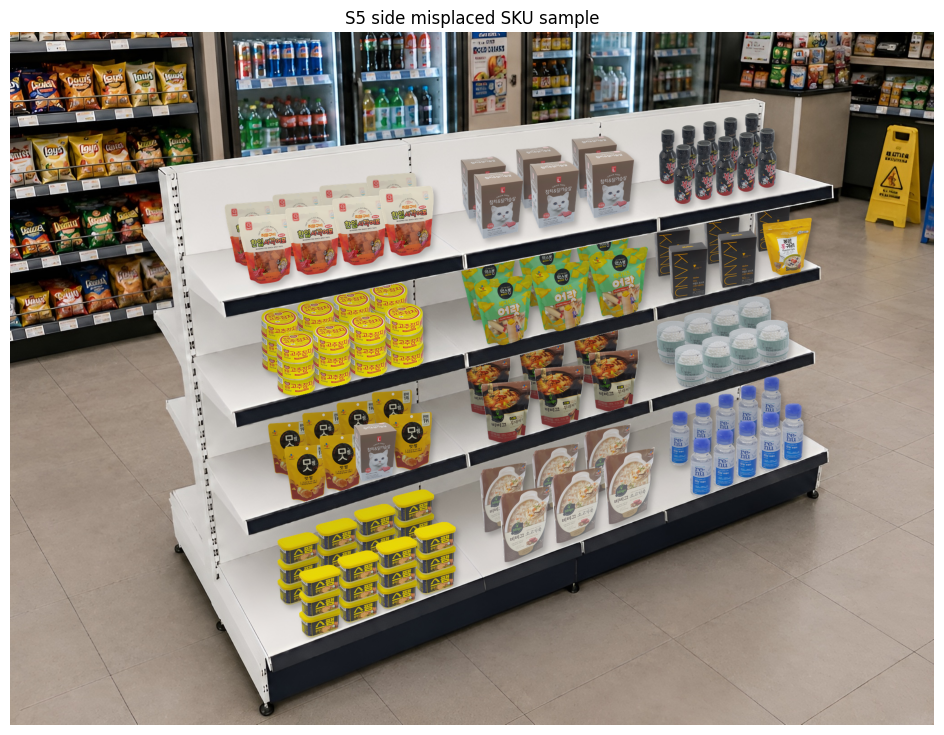

In [12]:
# ============================================================
# S5 측면 합성 + 이미지/라벨 저장
# 방식: S6처럼 extra_misplaced_items 사용
# ============================================================

for image_idx in range(NUM_IMAGES):
    seed = BASE_SEED + image_idx

    random.seed(seed)
    synth.reset_random_seed(seed)

    # ------------------------------------------------------------
    # 1. 이미지마다 ctx 새로 생성
    # ------------------------------------------------------------
    ctx = synth.create_synthetic_context(
        base_dir=BASE_DIR,
        background_name='선반이미지_사이드.png',
        seed=seed,
    )

    # ------------------------------------------------------------
    # 2. 정상 slot_plan 생성
    # ------------------------------------------------------------
    slot_plan = synth.make_normal_slot_plan(ctx)

    all_candidate_items = collect_all_candidate_items_from_ctx(ctx)

    candidate_slot_ids = [
        slot_id
        for slot_id, target in slot_plan.items()
        if int(target["normal_front_qty"]) > 0
        and not is_excluded_for_s5(target["target_product_id"])
    ]

    if len(candidate_slot_ids) == 0:
        raise ValueError("S5 오진열 후보 slot이 없습니다.")

    # ------------------------------------------------------------
    # 3. 오진열 slot 랜덤 선택
    # ------------------------------------------------------------
    selected_slot_ids = sample_nonempty_subset(
        candidate_slot_ids,
        prob_range=(0.12, 0.30)
    )

    random.shuffle(selected_slot_ids)

    s5_logs = []
    used_wrong_product_ids = set()

    # ------------------------------------------------------------
    # 4. 선택된 slot에 오진열 적용
    # 핵심: extra_misplaced_items 방식
    # ------------------------------------------------------------
    for slot_id in selected_slot_ids:
        target = slot_plan[slot_id]

        front_qty = int(target["normal_front_qty"])
        back_qty = int(target["normal_back_qty"])

        if front_qty <= 0:
            continue

        misplaced_index = random.randrange(front_qty)

        wrong_item = None

        for tol in [0.20, 0.25, 0.35, 0.50]:
            wrong_item = choose_wrong_item_by_width_for_side(
                all_candidate_items=all_candidate_items,
                target=target,
                width_tolerance=tol,
                avoid_product_ids=used_wrong_product_ids,
            )

            if wrong_item is not None:
                break

        if wrong_item is None:
            print("[S5 후보 없음 - skip]", slot_id, target["target_product_id"], target["target_product_name"])
            continue

        wrong_product_dir = wrong_item["product_dir"]
        wrong_product_id = str(wrong_item["product_id"])
        wrong_product_name = wrong_item["product_name"]

        used_wrong_product_ids.add(wrong_product_id)

        target.update({
            "scenario_code": SCENARIO_CODE,
            "scenario_name": SCENARIO_NAME,
            "sub_scenario_code": SCENARIO_CODE,
            "action": "misplaced_one_item",
            "list_up": True,
            "final_status": "확인 필요",

            # actual은 렌더링 기준 상품으로 유지
            # wrong SKU는 extra_misplaced_items로만 추가
            "actual_product_dir": target["target_product_dir"],
            "actual_product_id": target["target_product_id"],
            "actual_product_name": target["target_product_name"],

            # 기준 수량은 정상 기준 유지
            "display_qty": front_qty,
            "back_display_qty": back_qty,

            # 오진열 위치의 원래 앞줄 상품 1개 제거
            "front_missing_indices": [misplaced_index],

            # S6에서 잘 되는 방식과 동일하게 뒷줄은 유지
            "back_missing_indices": [],
            "back_visible_indices": None,

            # 핵심: 공통 py가 이 정보를 보고 wrong SKU를 실제로 붙임
            "extra_misplaced_items": [
                {
                    "product_dir": wrong_product_dir,
                    "product_id": wrong_product_id,
                    "product_name": wrong_product_name,
                    "position_index": misplaced_index,
                }
            ],

            # 오진열은 결손이 아니라 확인 필요
            "missing_qty": 0,
            "reduced_front_qty": front_qty,
            "target_column_index": None,
            "is_misplaced": True,

            # JSON/로그 확인용
            "misplaced_index": misplaced_index,
            "misplaced_product_id": wrong_product_id,
            "misplaced_product_name": wrong_product_name,
        })

        s5_logs.append({
            "slot_id": slot_id,
            "base_product_id": target["target_product_id"],
            "base_product_name": target["target_product_name"],
            "wrong_product_id": wrong_product_id,
            "wrong_product_name": wrong_product_name,
            "misplaced_index": misplaced_index,
            "base_width": wrong_item.get("base_width"),
            "wrong_width": wrong_item.get("wrong_width"),
            "width_diff": round(wrong_item.get("width_diff", 0), 3),
            "rule": "extra_misplaced_items 방식으로 공통 py에서 오진열 합성",
        })

    if len(s5_logs) == 0:
        print("[경고] 이 이미지에서 S5 오진열 적용 실패. seed:", seed)

    # ------------------------------------------------------------
    # 5. 나머지 정상 slot 처리
    # ------------------------------------------------------------
    for slot_id, target in slot_plan.items():
        if target.get("scenario_code") != SCENARIO_CODE:
            front_qty = int(target["normal_front_qty"])
            back_qty = int(target["normal_back_qty"])

            target.update({
                "scenario_code": SCENARIO_CODE,
                "scenario_name": SCENARIO_NAME,
                "sub_scenario_code": "NORMAL",
                "action": "normal",
                "list_up": False,
                "final_status": "정상",

                "display_qty": front_qty,
                "back_display_qty": back_qty,

                "front_missing_indices": [],
                "back_missing_indices": [],
                "back_visible_indices": None,
                "extra_misplaced_items": [],

                "missing_qty": 0,
                "reduced_front_qty": front_qty,
                "target_column_index": None,
                "is_misplaced": False,
            })

    # ------------------------------------------------------------
    # 6. 렌더링
    # 여기서 render_from_slot_plan이 extra_misplaced_items를 처리함
    # ------------------------------------------------------------
    result, objects, slot_labels = synth.render_from_slot_plan(
        ctx=ctx,
        slot_plan=slot_plan,
        seed=seed,
    )

    # ------------------------------------------------------------
    # 7. 저장 파일명
    # ------------------------------------------------------------
    file_no = start_idx + image_idx

    save_name = f"synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.png"
    yolo_name = f"synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.txt"
    json_name = f"synthetic_{SCENARIO_CODE.lower()}_{file_no:03d}.json"

    save_path = IMAGE_DIR / save_name
    product_yolo_path = PRODUCT_YOLO_DIR / yolo_name
    shelf_lip_yolo_path = SHELF_LIP_YOLO_DIR / yolo_name
    json_path = JSON_DIR / json_name

    # ------------------------------------------------------------
    # 8. 이미지 + SAHI 기준 라벨 3종 저장
    # ------------------------------------------------------------
    label_result = labeler.save_sahi_labels(
        result=result,
        objects=objects,
        slot_labels=slot_labels,
        ctx=ctx,
        scenario_code=SCENARIO_CODE,
        scenario_name=SCENARIO_NAME,
        image_path=save_path,
        product_yolo_path=product_yolo_path,
        shelf_lip_yolo_path=shelf_lip_yolo_path,
        slot_json_path=json_path,
        seed=seed,
        view="side",
        settings_extra={
            "excluded_product_ids_for_s5": sorted(list(EXCLUDE_MISPLACED_PRODUCT_IDS)),
            "width_tolerance_trials": [0.20, 0.25, 0.35, 0.50],
            "s5_method": "extra_misplaced_items",
            "rule": (
                "Original front item is removed and wrong SKU is passed "
                "to render_from_slot_plan through extra_misplaced_items."
            ),
        }
    )

    # ------------------------------------------------------------
    # 9. 저장된 JSON에 S5 상세 로그 추가
    # ------------------------------------------------------------
    with open(json_path, "r", encoding="utf-8") as f:
        label_json = json.load(f)

    label_json["s5_details"] = s5_logs

    if "settings" not in label_json:
        label_json["settings"] = {}

    label_json["settings"]["s5_method"] = "extra_misplaced_items"
    label_json["settings"]["excluded_product_ids_for_s5"] = sorted(list(EXCLUDE_MISPLACED_PRODUCT_IDS))
    label_json["settings"]["width_tolerance_trials"] = [0.20, 0.25, 0.35, 0.50]

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(label_json, f, ensure_ascii=False, indent=2)

    saved_paths.append(save_path)
    last_result = result

    generation_logs.append({
        "file_name": save_name,
        "seed": seed,
        "scenario_code": SCENARIO_CODE,
        "scenario_name": SCENARIO_NAME,
        "n_targets": len(s5_logs),
        "n_misplaced_slots": len(s5_logs),
        "targets": s5_logs,
        "n_objects": len(objects),
        "n_slots": len(slot_labels),
        "image_path": str(save_path),
        "product_yolo_path": str(product_yolo_path),
        "shelf_lip_yolo_path": str(shelf_lip_yolo_path),
        "json_path": str(json_path),
        "label_result": label_result,
    })

    if (image_idx + 1) % 20 == 0:
        print(f"[{image_idx + 1}/{NUM_IMAGES}] 생성 완료:", save_name, "| misplaced:", len(s5_logs))


print("S5 생성 완료")
print(f"총 생성 수: {len(saved_paths)}장")
print("이미지 저장 폴더:", IMAGE_DIR)
print("상품 YOLO 저장 폴더:", PRODUCT_YOLO_DIR)
print("선반 앞턱 YOLO-seg 저장 폴더:", SHELF_LIP_YOLO_DIR)
print("slot_state JSON 저장 폴더:", JSON_DIR)

print("처음 5개 파일:")
for p in saved_paths[:5]:
    print("-", p.name)

print("마지막 이미지:", saved_paths[-1])
synth.show_image(last_result, title=f"{SCENARIO_CODE} side misplaced SKU sample")

In [ ]:
# ============================================================
# S5 생성 결과 확인
# ============================================================

print("생성된 이미지 수:", len(saved_paths))
print()

last_log = generation_logs[-1]

print("마지막 생성 로그")
print("파일명:", last_log["file_name"])
print("seed:", last_log["seed"])
print("오진열 슬롯 수:", last_log["n_targets"])
print("objects 수:", last_log["n_objects"])
print("slots 수:", last_log["n_slots"])
print("image_path:", last_log["image_path"])
print("product_yolo_path:", last_log["product_yolo_path"])
print("shelf_lip_yolo_path:", last_log["shelf_lip_yolo_path"])
print("json_path:", last_log["json_path"])

print()
print("오진열 상세:")
for target in last_log["targets"]:
    print(target)